In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

DATA_PATH = Path("termobatidora.csv")
TIME   = "ts"
TARGET = "lab_humedad_alpeorujo"

COLS = ["ts",
        "T_pasta_e", "T_pasta_1", "T_pasta_2", "T_pasta_s",
        "T_agua_ida", "T_agua_ret", "T_ambiente",
        "caudal_pasta", "caudal_agua", "agua_proceso",
        "amperios_batidora", "nivel_batidora"]

data = pd.read_csv(DATA_PATH)[COLS].copy()
data[TIME] = pd.to_datetime(data[TIME])

data = data.sort_values(TIME).reset_index(drop=True)
print(f"{len(data):,} filas | {data[TIME].min()} -> {data[TIME].max()}")

c:\Users\COMPUTAEX\anaconda3\envs\aove\Lib\site-packages\xgboost\core.py:39: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  import scipy.sparse


4,320 filas | 2024-12-15 06:00:00 -> 2024-12-18 05:59:00


In [2]:
# Detectar NaN
print(data.isna().sum())

ts                   0
T_pasta_e            0
T_pasta_1            0
T_pasta_2            0
T_pasta_s            0
T_agua_ida           0
T_agua_ret           0
T_ambiente           0
caudal_pasta         0
caudal_agua          0
agua_proceso         0
amperios_batidora    0
nivel_batidora       0
dtype: int64


In [3]:
resumen = data.drop(columns=[TIME]).agg(
    ["count", "min", "max", "mean", "median", "std", "skew"]
).T

resumen["missing"] = data.drop(columns=[TIME]).isna().sum()
resumen["iqr"] = (
    data.drop(columns=[TIME]).quantile(0.75)
    - data.drop(columns=[TIME]).quantile(0.25)
)
resumen["outliers_iqr"] = [
    (
        (data[col] < data[col].quantile(0.25) - 1.5 * resumen.loc[col, "iqr"])
        | (data[col] > data[col].quantile(0.75) + 1.5 * resumen.loc[col, "iqr"])
    ).sum()
    for col in resumen.index
]

resumen.round(3)

,count,min,max,mean,median,std,skew,missing,iqr,outliers_iqr
T_pasta_e,4320.0,8.208,24.845,16.715,16.734,4.579,0.021,0,7.811,0
T_pasta_1,4320.0,13.901,28.419,21.060,21.388,3.198,-0.220,0,5.092,0
T_pasta_2,4320.0,18.623,31.903,24.701,25.164,2.281,-0.461,0,3.089,12
T_pasta_s,4320.0,22.939,34.734,27.774,28.176,1.934,-0.287,0,3.145,12
T_agua_ida,4320.0,29.424,68.733,54.803,59.300,12.506,-0.486,0,22.537,0
T_agua_ret,4320.0,28.764,62.476,50.110,53.751,10.457,-0.507,0,18.628,0
T_ambiente,4320.0,4.180,17.780,11.001,10.980,4.254,0.003,0,8.462,0
caudal_pasta,4320.0,0.000,9614.600,7217.553,7119.450,1680.334,-0.917,0,3043.325,53
caudal_agua,4320.0,3.951,6.857,4.945,4.973,0.494,0.606,0,0.457,252
agua_proceso,4320.0,0.000,1212.600,426.273,420.000,360.439,0.776,0,415.400,137


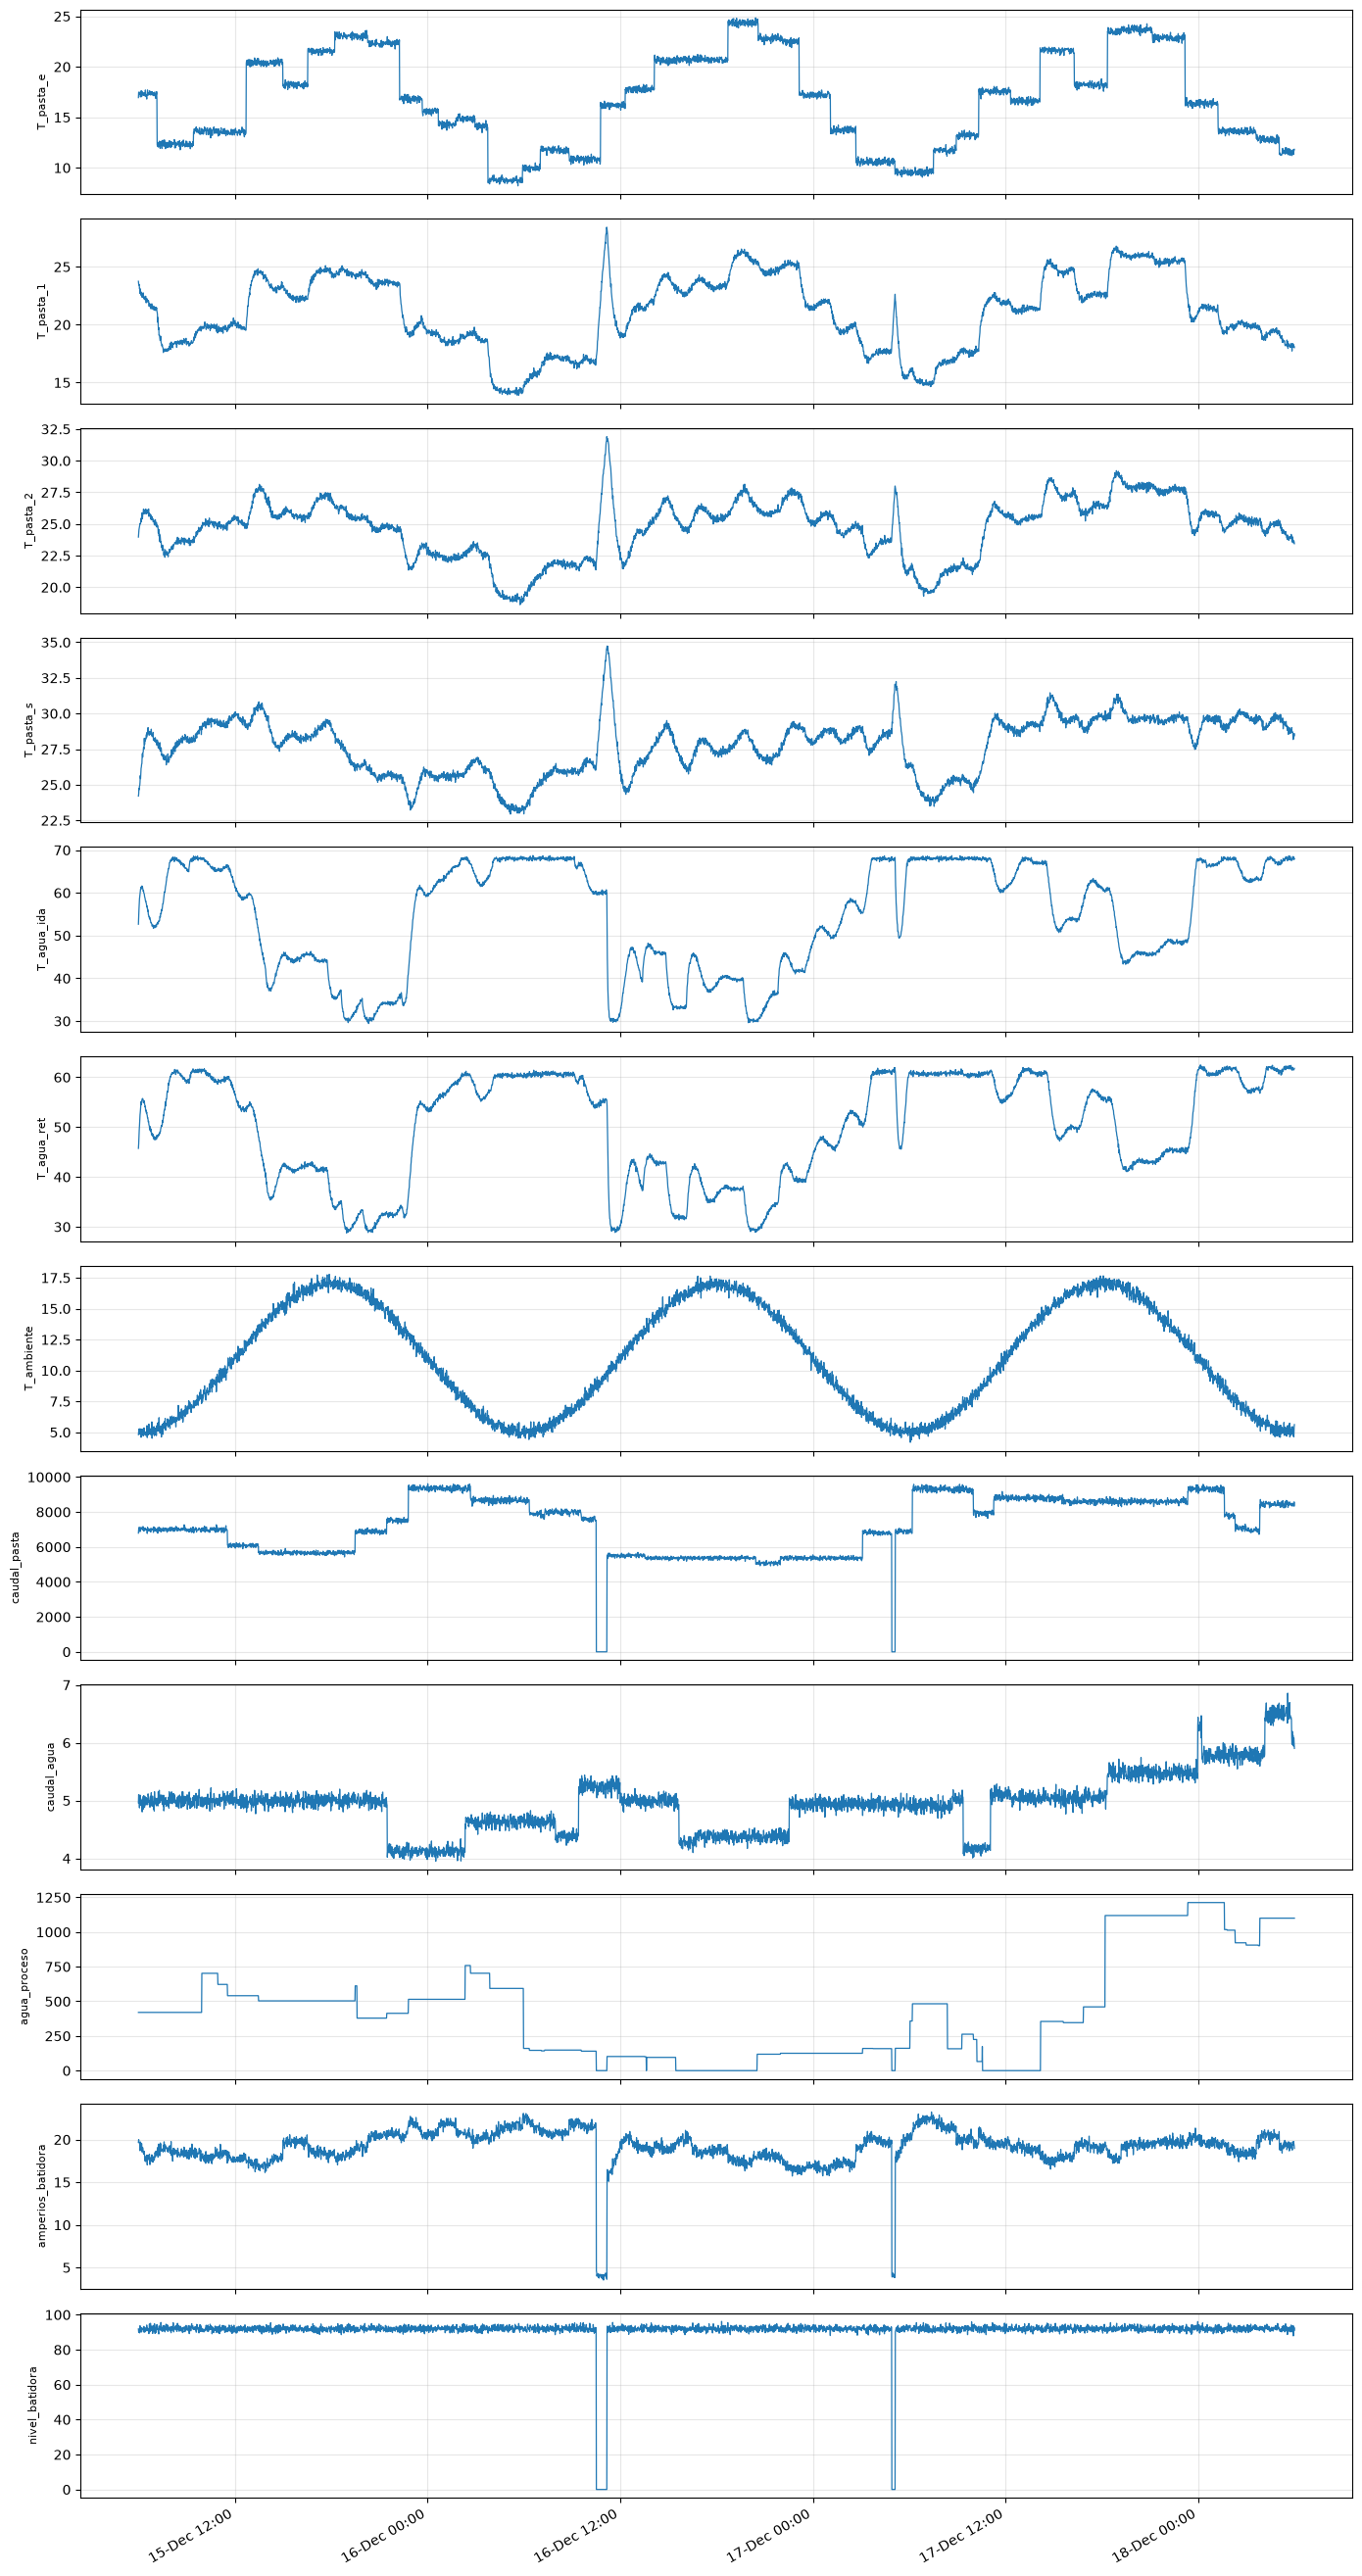

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(COLS) - 1, 1, figsize=(14, 2.2 * (len(COLS) - 1)), sharex=True)

for ax, col in zip(axes, [c for c in COLS if c != "ts"]):
    ax.plot(data["ts"], data[col], linewidth=0.9)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

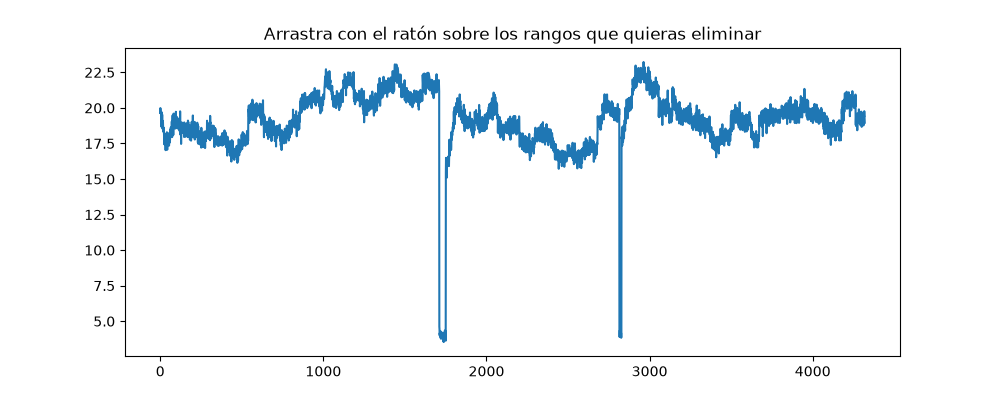

In [5]:
%matplotlib widget
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector
import pandas as pd

# 1. PREPARAR EL DATAFRAME ANTES DE GRAFICAR
# Asegurarnos de que 'ts' es el índice de tipo datetime
if "ts" in data.columns:
    data["ts"] = pd.to_datetime(data["ts"])
    df_plot = data.set_index("ts").sort_index()
else:
    df_plot = data.copy()

rangos_a_eliminar = []

def onselect(xmin, xmax):
    print(xmin, xmax)
    # Ahora xmin y xmax sí corresponden a fechas reales en Matplotlib
    inicio = pd.Timestamp(data["ts"][int(xmin)]).tz_localize(None)
    fin = pd.Timestamp(data["ts"][int(xmax)]).tz_localize(None)

    rangos_a_eliminar.append((inicio, fin))

    # Actualizar título para confirmar
    txt = f"Añadido: {inicio.strftime('%Y-%m-%d')} a {fin.strftime('%Y-%m-%d')} (Total: {len(rangos_a_eliminar)})"
    ax.set_title(txt, color="green", fontsize=10)
    fig.canvas.draw_idle()

    print(f"✓ Guardado: {inicio} -> {fin}")


# Crear la figura interactiva
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(data.index, data["amperios_batidora"], label="Datos")
ax.set_title("Arrastra con el ratón sobre los rangos que quieras eliminar")

fig.canvas.toolbar.mode = ""

# Iniciar el SpanSelector
fig.span = SpanSelector(
    ax,
    onselect,
    "horizontal",
    useblit=False,
    interactive=True,
    props=dict(alpha=0.4, facecolor="red"),
)

plt.show()

In [6]:
import pandas as pd



# 1. Copiar y preparar el DataFrame asignando 'ts' como DatetimeIndex
df_ordenado = data.copy()

# Asegurar que 'ts' sea de tipo datetime y establecerla como índice
df_ordenado["ts"] = pd.to_datetime(df_ordenado["ts"])
df_ordenado = df_ordenado.set_index("ts").sort_index()

# 2. Obtener el inicio y fin del dataset completo
inicio_global = df_ordenado.index[0]
fin_global = df_ordenado.index[-1]

# Convertir rangos seleccionados a Timestamp
rangos_limpios = [
    (pd.Timestamp(inicio), pd.Timestamp(fin)) for inicio, fin in rangos_a_eliminar
]
rangos_ordenados = sorted(rangos_limpios, key=lambda x: x[0])

# 3. Construir los intervalos a conservar
intervalos_conservar = []
punto_actual = inicio_global

for inicio_elim, fin_elim in rangos_ordenados:
    if inicio_elim > fin_global or fin_elim < inicio_global:
        continue

    inicio_elim = max(inicio_elim, inicio_global)
    fin_elim = min(fin_elim, fin_global)

    if punto_actual < inicio_elim:
        intervalos_conservar.append((punto_actual, inicio_elim))

    punto_actual = max(punto_actual, fin_elim)

if punto_actual < fin_global:
    intervalos_conservar.append((punto_actual, fin_global))

# 4. Extraer sub-DataFrames sin fugas de datos
bloques = []
for inicio, fin in intervalos_conservar:
    sub_df = df_ordenado.loc[inicio:fin]
    if not sub_df.empty:
        bloques.append(sub_df)

# --- RESULTADO ---
print(f"📌 Primera fecha real: {inicio_global}")
print(f"📌 Última fecha real:  {fin_global}\n")
print(f"✂️ Se dividió en {len(bloques)} bloques independientes:\n")
for i, b in enumerate(bloques, 1):
    print(
        f"📦 Bloque {i}: {b.index.min()}  -->  {b.index.max()} | ({len(b)} registros)"
    )

📌 Primera fecha real: 2024-12-15 06:00:00
📌 Última fecha real:  2024-12-18 05:59:00

✂️ Se dividió en 1 bloques independientes:

📦 Bloque 1: 2024-12-15 06:00:00  -->  2024-12-18 05:59:00 | (4320 registros)


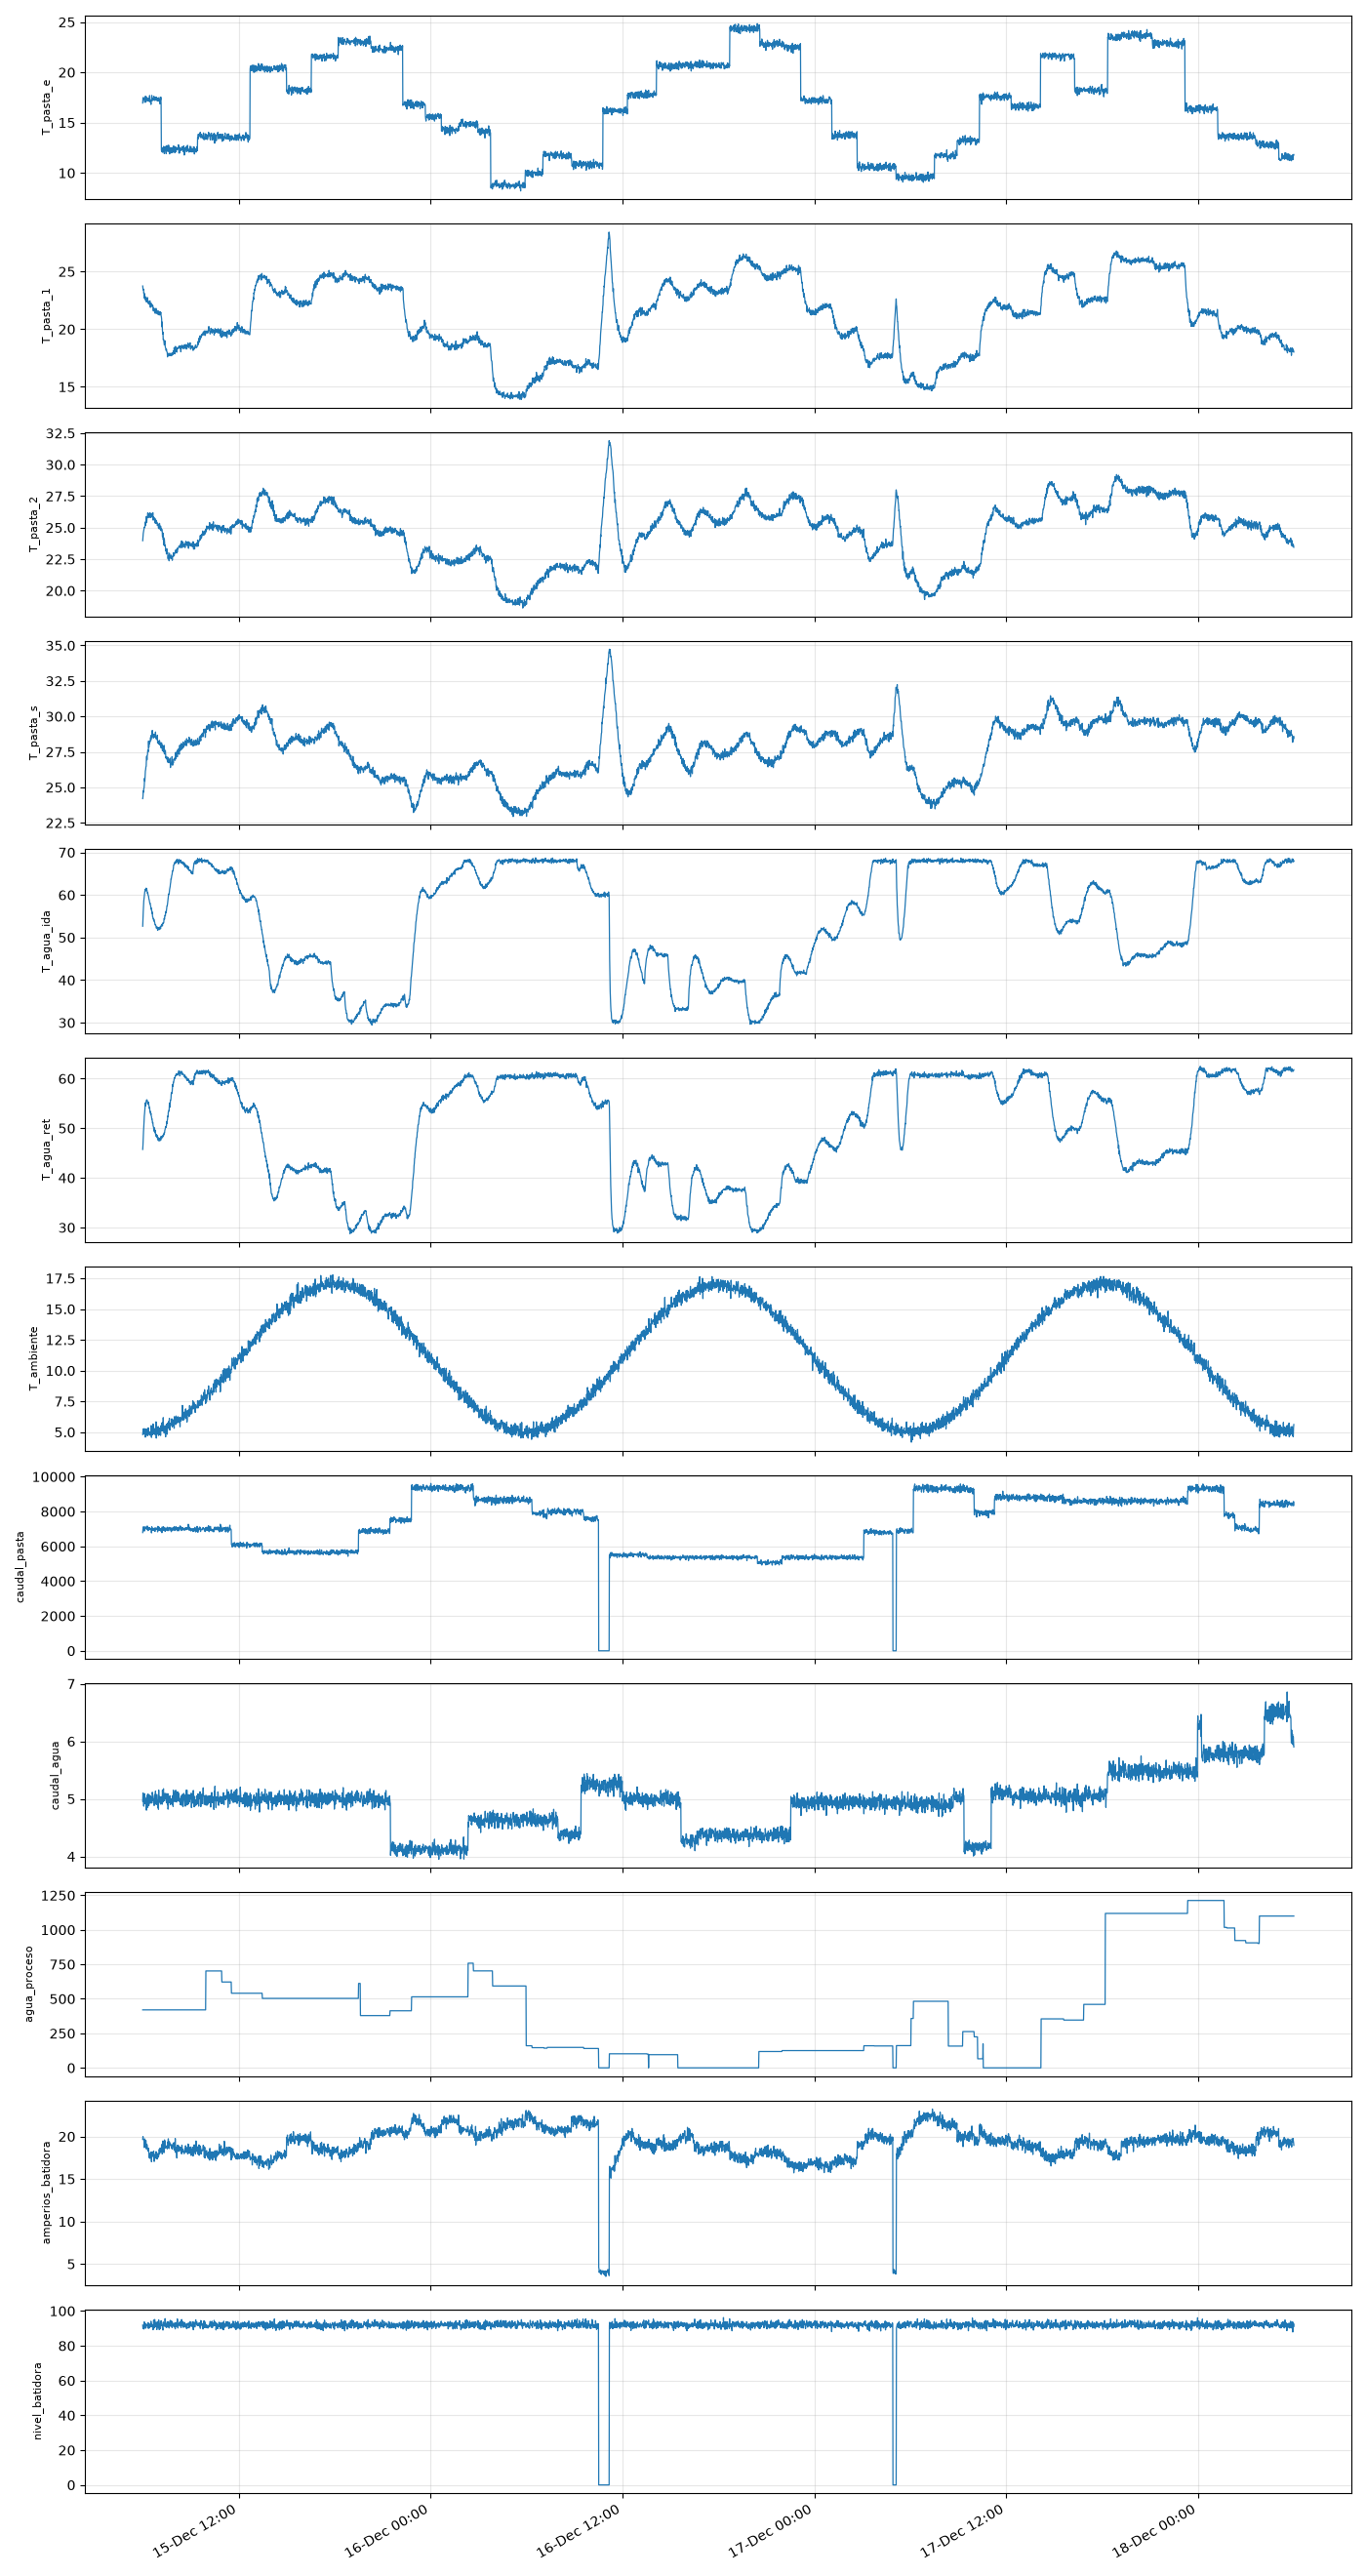

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(COLS) - 1, 1, figsize=(14, 2.2 * (len(COLS) - 1)), sharex=True)

for ax, col in zip(axes, [c for c in COLS if c != "ts"]):
    ax.plot(data["ts"], data[col], linewidth=0.9)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

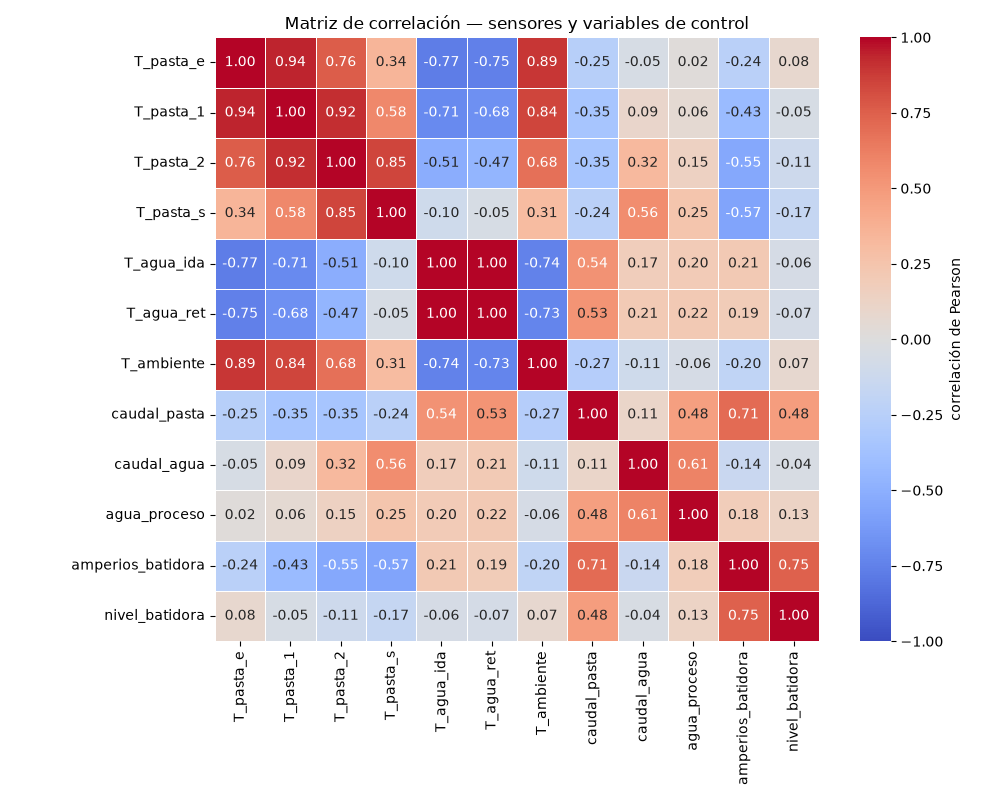

In [8]:
# Matriz de correlación

import matplotlib.pyplot as plt
import seaborn as sns

VARIABLES = ["T_pasta_e", "T_pasta_1", "T_pasta_2", "T_pasta_s",
             "T_agua_ida", "T_agua_ret", "T_ambiente",
             "caudal_pasta", "caudal_agua", "agua_proceso",
             "amperios_batidora", "nivel_batidora"]

corr = data[VARIABLES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"label": "correlación de Pearson"}, ax=ax,
)
ax.set_title("Matriz de correlación — sensores y variables de control")
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# ---------------------------------------------------------------------------
# 1. Carga y variables mínimas
#    Las 4 del paper (Bordons & Zafra): caudal y T de pasta, caudal y T de agua.
#    A diferencia del paper, aquí SÍ necesitamos T_agua_ida como ACCIÓN FUTURA,
#    no solo como estado pasado: el paper hacía nowcasting (¿cuánto vale la
#    salida ahora?), nosotros hacemos forecasting condicionado a una acción
#    (¿cuánto valdrá la salida en 15 min SI hago tal cosa?). Sin la acción
#    futura como input, el modelo solo aprendería inercia, no causalidad, y
#    no serviría para prescribir.
# ---------------------------------------------------------------------------

BASE = ["T_pasta_s", "caudal_pasta", "T_agua_ida", "caudal_agua"]
LAGS = [0, 5, 10, 15, 30]     # min; compatible con los retardos de 4.5-8 min
                              # y tiempos característicos de 4-7 min del paper
H = 5                        # horizonte de predicción, en minutos

# ---------------------------------------------------------------------------
# 2. Características
# ---------------------------------------------------------------------------
X = pd.DataFrame(index=data.index)
for v in BASE:
    for lag in LAGS:
        X[f"{v}_lag{lag}"] = data[v].shift(lag)

# Acción futura: media de T_agua_ida en la ventana (t, t+H].
# Es lo que el prescriptor cambiará luego para evaluar "qué pasaría si..."
X["T_agua_ida_fut"] = data["T_agua_ida"].shift(-H).rolling(H, min_periods=1).mean()
X["T_agua_ida_fut_delta"] = X["T_agua_ida_fut"] - data["T_agua_ida"]

# ---------------------------------------------------------------------------
# 3. Objetivo: el INCREMENTO de T_pasta_s, no el nivel
#    (T_pasta_s es medible online -> modelar el delta bate a modelar el nivel,
#    porque el modelo solo tiene que explicar la deriva, no el valor absoluto)
# ---------------------------------------------------------------------------
y_futuro = data["T_pasta_s"].shift(-H)
y = y_futuro - data["T_pasta_s"]

# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# 5. Partición TEMPORAL (nunca aleatoria en series temporales)
# ---------------------------------------------------------------------------
rf_train_X, rf_test_X, rf_train_y, rf_test_y = train_test_split(
    X, y, test_size=.20, random_state=0, shuffle=False)

# ---------------------------------------------------------------------------
# 6. Entrenamiento
# ---------------------------------------------------------------------------
modelo = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=0,
)
modelo.fit(rf_train_X, rf_train_y)

# ---------------------------------------------------------------------------
# 7. Evaluación contra la línea base honesta: la persistencia
#    (T_pasta_s es medible ahora mismo; si el modelo no bate a "seguirá igual",
#    no aporta nada)
# ---------------------------------------------------------------------------
pred = modelo.predict(rf_test_X)
real = rf_test_y

print(f"MAE modelo      : {mean_absolute_error(real, pred):.3f}")
print(f"R2 modelo       : {r2_score(real, pred):.3f}")
# print(f"MAE persistencia: {mean_absolute_error(real, baseline):.3f}")

# ---------------------------------------------------------------------------
# 8. Comprobación de direccionalidad (imprescindible antes de prescribir)
#    Sube T_agua_ida +5°C en el horizonte futuro y comprueba que T_pasta_s
#    sube también. Si el signo no coincide, el modelo NO está listo para
#    prescribir por buen MAE que tenga.
# ---------------------------------------------------------------------------
# base_pred = modelo.predict(rf_test_X)
# X_pert = rf_test_X.copy()
# X_pert["T_agua_ida_fut"] += 5.0
# X_pert["T_agua_ida_fut_delta"] += 5.0
# delta = np.mean(modelo.predict(X_pert) - base_pred)
# print(f"\nSensibilidad: +5°C en T_agua_ida -> {delta:+.3f}°C en T_pasta_s a {H} min")
# print("(esperado: positivo; en el simulador la respuesta medida por escalón es ~+0.36°C)")

ValueError: Input contains NaN.